# Task 1 — Popularity Regression

Predict continuous **popularity** (0-100) from audio features, artist and genre.

**Models:** Linear Regression, Polynomial Regression, Ridge, Lasso, ElasticNet, Random Forest, XGBoost, MLPRegressor 
**Metrics:** RMSE, MAE, R²  
**Validation:** 5-fold CV + `RandomizedSearchCV` for hyperparameters tuning on the best candidates

#### Setup and data splitting

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# imports from src folder
from src import config
from src.data_preprocessor import load_and_clean_data
from src.pipeline import build_preprocessor

RANDOM_STATE = 42

The function `load_and_clean_data` loads raw data, deduplicate tracks with same track_name and artists (keeping the one with the higher popularity), and drop rows with missing data.

In [2]:
df = load_and_clean_data(str(ROOT / config.DATA_PATH))
print(f"Data shape: {df.shape}")

Data shape: (81343, 20)


Data split into train and test (80/20), stratifying by track_genre.

In [3]:
target = config.TARGET_REG  # popularity
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    stratify = df['track_genre'],
    random_state = RANDOM_STATE
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (65074, 19), Test shape: (16269, 19)


In [4]:
X_train.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
55962,58VEPMPowIVTIL3t3Vjel7,Pritam;Daler Mehndi,Singh Is Kinng,Bhootni Ke,305266,0,0.773,0.941,10,-2.292,0,0.0834,0.09490,0.0103,0.0916,0.8630,130.050,4,indian
75406,0HWuQaqhb0CdLYTQm86Bd6,ERA,Classics II,Prelude,204986,0,0.194,0.210,0,-17.654,1,0.0383,0.82300,0.7930,0.1060,0.0390,79.311,3,new-age
17417,1PRpJKvfeaOPhJW39ecgw2,One True God;ARIUS,Misbehave,Misbehave,163298,0,0.677,0.697,5,-4.200,0,0.0346,0.04280,0.0240,0.1670,0.2130,96.987,4,club
27374,4ynE1hHNJwpW1zIJcFXkuA,Turno,Vision,The Invaderz,274482,0,0.543,0.925,11,-0.815,0,0.0764,0.00134,0.5900,0.0922,0.0718,174.029,4,drum-and-bass
37532,1W0sYOma39HqEh4UO8Aq3i,Menor MC;DJ Matt D,Trap Funk Star,Líquido Roxo,123769,0,0.845,0.308,1,-9.717,0,0.7030,0.04330,0.0000,0.1620,0.3460,134.442,4,funk


#### Stratified K-Fold on training set for cross validation

Using Stratified K-Fold on track_genre, splitting train into 5 folds, one used for (cross) validation.

In [5]:
# Stratified K-Fold on track_genre (not on target)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(X_train, X_train['track_genre']))

print(f"Number of folds: {len(cv_splits)}")
print(f"Average dimension of validation fold: {np.mean([len(v) for _, v in cv_splits]):.0f}")

Number of folds: 5
Average dimension of validation fold: 13015


Building the pipeline for each model -> different feature encodings and scaling for each model family (see `pipeline.py` file).

In [6]:
# preprocessors for linear models and tree-based models
prep_linear = build_preprocessor(model_family='linear', task='regression')
prep_tree = build_preprocessor(model_family='tree', task='regression')
prep_poly = build_preprocessor(model_family="linear", task="regression", poly_degree=2)

#### Candidate Models

Initial fit with a Dummy Regressor and different models to see the ones that perform better with a standard configuration.

In [8]:
# Confronto fra famiglie di modelli con iperparametri di default (baseline) e preprocessori adatti a ciascuna famiglia di modelli
candidates = {
    "Baseline (mean)": Pipeline([("prep", clone(prep_linear)), ("model", DummyRegressor(strategy="mean"))]),
    "Linear Regression": Pipeline([("prep", clone(prep_linear)), ("model", LinearRegression())]),
    "Ridge": Pipeline([("prep", clone(prep_linear)), ("model", Ridge(random_state=RANDOM_STATE))]),
    "Polynomial + Ridge": Pipeline([("prep", clone(prep_poly)), ("model", Ridge())]),
    "Lasso": Pipeline([("prep", clone(prep_linear)), ("model", Lasso(max_iter=5000, random_state=RANDOM_STATE))]),
    "ElasticNet": Pipeline([("prep", clone(prep_linear)), ("model", ElasticNet(max_iter=5000, random_state=RANDOM_STATE))]),
    "MLP": Pipeline([("prep", clone(prep_linear)), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", clone(prep_tree)), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))]),
    "XGBoost": Pipeline([("prep", clone(prep_tree)), ("model", XGBRegressor(random_state = RANDOM_STATE, n_jobs=1))]),
}

results = []

for name, pipe in candidates.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv_splits,
        scoring=["neg_root_mean_squared_error", "r2"],
        n_jobs=-1,
    )
    results.append({
        "model": name,
        "rmse": -scores["test_neg_root_mean_squared_error"].mean(),
        "rmse_std": scores["test_neg_root_mean_squared_error"].std(),
        "r2": scores["test_r2"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("rmse")
results_df

,model,rmse,rmse_std,r2
6,MLP,14.524898,0.057956,0.439039
7,Random Forest,14.622808,0.042675,0.431433
3,Polynomial + Ridge,14.801185,0.047405,0.417491
2,Ridge,14.853849,0.039893,0.413338
1,Linear Regression,14.853955,0.040011,0.413329
8,XGBoost,14.861326,0.047847,0.412729
5,ElasticNet,19.001799,0.060707,0.039969
4,Lasso,19.006395,0.062078,0.039505
0,Baseline (mean),19.394171,0.064083,-0.000086


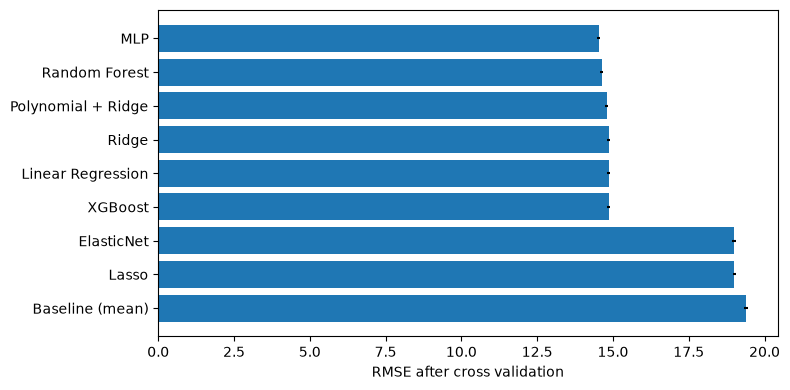

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results_df["model"], results_df["rmse"], xerr=results_df["rmse_std"])
ax.set_xlabel("RMSE after cross validation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Since Ridge and Linear Regression have the same performance and correlation between continuous feature is moderate (see EDA notebook), dimensionality reduction (PCA) or feature selection techniques are not applied.

#### Hyperparameters Tuning
Since LR has no hyperparameters to tune, I will keep the top5 models, so RF, Xgboost, MPL, Ridge and Polynomial and perform a random search over a standard set of hyperparameters.

In [10]:
top_candidates = ["MLP", "Random Forest", "Ridge", "Polynomial + Ridge", "XGBoost"]

param_distributions = {
    "MLP": {
        "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
        "model__alpha": np.logspace(-4, -1, 10),  # L2 penalty
        "model__learning_rate_init": [0.001, 0.005, 0.01],
    },
    "Random Forest": {
        "model__n_estimators": [400, 600, 800, 1000],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 1.0]
    },
    "Ridge": {"model__alpha": np.logspace(-3, 3, 20)},
    "Polynomial + Ridge": {
        "model__alpha": np.logspace(-3, 3, 20),
        "prep__continuous__poly__degree": [2, 3],
    },
    "XGBoost": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [3, 5, 7, 9],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
}

n_iter_by_model = {
    "MLP": 25,
    "Random Forest": 30,  # more parameters to search
    "Ridge": 20,
    "Polynomial + Ridge": 25,
    "XGBoost": 20,  # it takes more time
}

tuned_results = {}
for name in top_candidates:
    search = RandomizedSearchCV(
        candidates[name],
        param_distributions[name],
        n_iter=n_iter_by_model[name],
        cv=cv_splits,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_results[name] = search
    print(f"{name}: best RMSE = {-search.best_score_:.3f}, best_params = {search.best_params_}")

MLP: best RMSE = 14.479, best_params = {'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (128,), 'model__alpha': np.float64(0.004641588833612777)}
Random Forest: best RMSE = 14.503, best_params = {'model__n_estimators': 1000, 'model__min_samples_leaf': 10, 'model__max_features': 1.0, 'model__max_depth': 20}
Ridge: best RMSE = 14.854, best_params = {'model__alpha': np.float64(2.976351441631316)}
Polynomial + Ridge: best RMSE = 14.801, best_params = {'prep__continuous__poly__degree': 2, 'model__alpha': np.float64(0.3359818286283781)}
XGBoost: best RMSE = 14.565, best_params = {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}


In [11]:
best_name = min(tuned_results, key=lambda n: -tuned_results[n].best_score_)
best_model = tuned_results[best_name].best_estimator_  # già rifittato su tutto X_train da RandomizedSearchCV

print(f"Final model selected: {best_name}")
print(f"Hyperparameters: {tuned_results[best_name].best_params_}")
print(f"RMSE CV: {-tuned_results[best_name].best_score_:.3f}")

Final model selected: MLP
Hyperparameters: {'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (128,), 'model__alpha': np.float64(0.004641588833612777)}
RMSE CV: 14.479


#### HURDLE MODEL

Hypotehsis: If I give in input to the regressor the outcome of the binary classification (!=0 and >0 popularity), the models' performances will improve by having to predict only the >0 popularity.

Checking between two standard classification models who gets the best performance and keeping it.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

y_train_binary = (y_train > 0).astype(int)
prep_tree_bin = build_preprocessor(model_family="tree", task="regression", target_type="binary")
prep_linear_bin = build_preprocessor(model_family="linear", task="regression")  # OHE, non serve genre_target_type

clf_candidates = {
    "LogisticRegression": Pipeline([("prep", clone(prep_linear_bin)),
                                     ("model", LogisticRegression(class_weight="balanced", max_iter=1000))]),
    "RandomForestClassifier": Pipeline([("prep", clone(prep_tree_bin)),
                                         ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
}

for name, pipe in clf_candidates.items():
    scores = cross_validate(pipe, X_train, y_train_binary, cv=cv_splits,
                             scoring=["f1", "roc_auc"], n_jobs=-1)
    print(f"{name}: F1={scores['test_f1'].mean():.3f}, ROC-AUC={scores['test_roc_auc'].mean():.3f}")

LogisticRegression: F1=0.892, ROC-AUC=0.888
RandomForestClassifier: F1=0.971, ROC-AUC=0.888


In [ ]:
from sklearn.metrics import mean_squared_error

def evaluate_hurdle(X, y, clf_pipeline, reg_pipeline, cv_splits):
    rmses = []
    for train_idx, val_idx in cv_splits:
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        clf = clone(clf_pipeline)
        clf.fit(X_tr, (y_tr > 0).astype(int))

        mask_nz = y_tr > 0
        reg = clone(reg_pipeline)
        reg.fit(X_tr[mask_nz], y_tr[mask_nz])

        is_nonzero_pred = clf.predict(X_val)
        preds = np.zeros(len(X_val))
        if is_nonzero_pred.sum() > 0:
            preds[is_nonzero_pred == 1] = reg.predict(X_val[is_nonzero_pred == 1])

        rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
    return np.mean(rmses), np.std(rmses)

best_clf = clf_candidates["RandomForestClassifier"]  # best classifier

tuned_estimators = {
    "MLP": tuned_results["MLP"].best_estimator_,
    "Random Forest": tuned_results["Random Forest"].best_estimator_,
    "XGBoost": tuned_results["XGBoost"].best_estimator_,
}

for reg_name, reg_pipeline in tuned_estimators.items():
    mean_rmse, std_rmse = evaluate_hurdle(X_train, y_train, best_clf, reg_pipeline, cv_splits)
    print(f"Hurdle + {reg_name}: RMSE = {mean_rmse:.3f} ± {std_rmse:.3f}")

Hurdle + MLP: RMSE = 15.431 ± 0.161
Hurdle + Random Forest: RMSE = 15.349 ± 0.113
Hurdle + XGBoost: RMSE = 15.395 ± 0.116


The hypothesis is not confirmed, I cannot observe a significant imporvement in RMSE. It is almost the same as a single stage regression.

#### Adding a new feature (artist popularity)

Adding information about the artists by target encoding that column, so an artist is encoded as mean of popularity. To prevent data leakage, shrinkage and cross fitting are applied, as with the track_genre feature.

In [18]:
prep_tree_artist = build_preprocessor("tree", use_artist=True)
prep_linear_artist = build_preprocessor("linear", use_artist=True)
prep_linear_artist_poly = build_preprocessor("linear", poly_degree=2, use_artist=True)

candidates_v2 = {
    "Ridge + artist": Pipeline([("prep", clone(prep_linear_artist)), ("model", Ridge(alpha=2.976))]),
    "MLP + artist": Pipeline([("prep", clone(prep_linear_artist)), ("model", MLPRegressor(hidden_layer_sizes=(128,), alpha=0.1, learning_rate_init=0.0046, max_iter=500, early_stopping=True, random_state=RANDOM_STATE))]),
    "Random Forest + artist": Pipeline([("prep", clone(prep_tree_artist)), ("model", RandomForestRegressor(n_estimators=1000, max_depth=20, max_features=1.0, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=1))]),
    "Polynomial + Ridge + artist": Pipeline([("prep", clone(prep_linear_artist_poly)), ("model", Ridge(alpha=0.336))]),
    "XGBoost + artist": Pipeline([("prep", clone(prep_tree_artist)), ("model", XGBRegressor(n_estimators=600, max_depth=7, learning_rate=0.01, colsample_bytree=0.85))])
}

results_v2 = []
for name, pipe in candidates_v2.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv_splits,
                             scoring=["neg_root_mean_squared_error", "r2"], n_jobs=-1)
    results_v2.append({"model": name, "rmse": -scores["test_neg_root_mean_squared_error"].mean(), "r2": scores["test_r2"].mean()})

pd.DataFrame(results_v2).sort_values("rmse")

,model,rmse,r2
2,Random Forest + artist,13.004764,0.550304
4,XGBoost + artist,13.053563,0.546923
1,MLP + artist,13.176736,0.538341
3,Polynomial + Ridge + artist,13.484463,0.516519
0,Ridge + artist,13.518987,0.514042


Adding artist information have a moderate but significant on the performance.

Checking if also other models (Lasso and ELastic Net) benefit from this new feature.

In [17]:
prep_linear_artist = build_preprocessor("linear", use_artist=True)
candidates_v3 = {
    "Lasso + artist": Pipeline([("prep", clone(prep_linear_artist)), ("model", Lasso(max_iter=5000, random_state=RANDOM_STATE))]),
    "ElasticNet + artist": Pipeline([("prep", clone(prep_linear_artist)), ("model", ElasticNet(max_iter=5000, random_state=RANDOM_STATE))])
}

results_v3 = []
for name, pipe in candidates_v3.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv_splits,
                             scoring=["neg_root_mean_squared_error", "r2"], n_jobs=-1)
    results_v3.append({"model": name, "rmse": -scores["test_neg_root_mean_squared_error"].mean(), "r2": scores["test_r2"].mean()})

pd.DataFrame(results_v3).sort_values("rmse")  

,model,rmse,r2
0,Lasso + artist,14.874610,0.411716
1,ElasticNet + artist,15.443366,0.365870


Despite adding the artist feature, Lasso and ELasticNet remain behind the other candidates.

#### Hyperparameters Tuning

**Tuning hyperparameters again on the 3 best models** (after adding artist_popularity).

In [21]:
param_distributions_v2 = {
    "Random Forest + artist": {
        "model__n_estimators": [400, 600, 800, 1000],
        "model__max_depth": [15, 20, 25, 30, None],
        "model__min_samples_leaf": [1, 2, 3],
        "model__max_features": [0.7, 1.0, "sqrt"],
    },
    "MLP + artist": {
        "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32)],
        "model__alpha": np.logspace(-3, -1, 8),
        "model__learning_rate_init": [0.001, 0.005],
    },
    "XGBoost + artist": {
        "model__n_estimators": [400, 600, 800],
        "model__max_depth": [3, 5, 7, 9],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
}

tuned_v2 = {}
for name in ["Random Forest + artist", "MLP + artist", "XGBoost + artist"]:
    search = RandomizedSearchCV(
        candidates_v2[name], param_distributions_v2[name],
        n_iter=15, cv=cv_splits, scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_v2[name] = search
    print(f"{name}: best RMSE = {-search.best_score_:.3f}, params = {search.best_params_}")

Random Forest + artist: best RMSE = 12.980, params = {'model__n_estimators': 800, 'model__min_samples_leaf': 3, 'model__max_features': 'sqrt', 'model__max_depth': 30}
MLP + artist: best RMSE = 13.131, params = {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (128,), 'model__alpha': np.float64(0.0019306977288832496)}
XGBoost + artist: best RMSE = 13.030, params = {'model__subsample': 0.7, 'model__n_estimators': 800, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}


#### Validation results on best model

RF + artist was proven to be the best model rather than MLP (and also more explainable). Seeing on plots some results after validation.

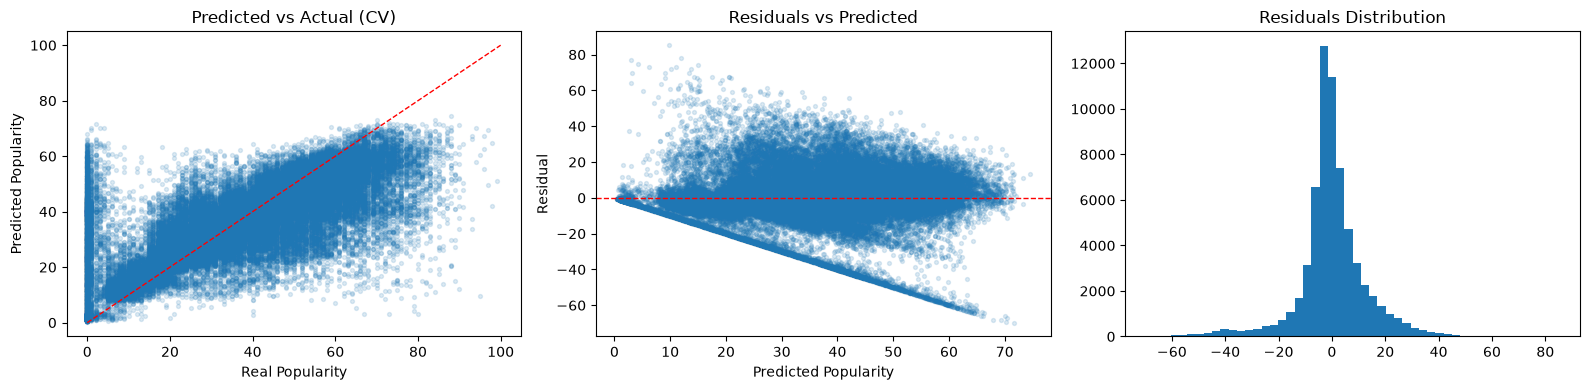

In [ ]:
best_name = min(tuned_v2, key=lambda n: -tuned_v2[n].best_score_)
best_model = tuned_v2[best_name].best_estimator_

# Val prediction via CV
from sklearn.model_selection import cross_val_predict
y_pred_cv = cross_val_predict(best_model, X_train, y_train, cv=cv_splits)
residuals = y_train.values - y_pred_cv

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs Actual
axes[0].scatter(y_train, y_pred_cv, alpha=0.15, s=8)
axes[0].plot([0, 100], [0, 100], "r--", lw=1)
axes[0].set_xlabel("Real Popularity"); axes[0].set_ylabel("Predicted Popularity")
axes[0].set_title("Predicted vs Actual (CV)")

# Residuals vs predicted
axes[1].scatter(y_pred_cv, residuals, alpha=0.15, s=8)
axes[1].axhline(0, color="r", linestyle="--", lw=1)
axes[1].set_xlabel("Predicted Popularity"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

# Residuals Distribution
axes[2].hist(residuals, bins=50)
axes[2].set_title("Residuals Distribution")
plt.tight_layout(); plt.show()

**Where model fails**: A lot of tracks with 0 popularity are labelled from 0 to 65, it can make sense since songs with similar audio features can be less popular if the artist is uknown to the big public.

An addition explanation for the vertical spread at Actual=0 can be that if an artist has one big hit and another track with popularity close to 0 (a remix or a less promoted release), the encoding assigns both tracks the same high artist popularity, pushing the model to overestimate the flop. This could be a limitation of the artist-level aggragation: it captures how famous an artist is on average but not why a specific track differs from the artist's other tracks. To mitigate this problem, other features (e.g. about track promotion or releasing timing) would be required.

#### Exploring results

Top 10 most wrongly predictedd genres.

In [15]:
error_df = pd.DataFrame({"genre": X_train["track_genre"].values, "abs_error": np.abs(residuals)})
top_worst_genres = error_df.groupby("genre")["abs_error"].mean().sort_values(ascending=False).head(10)
print(top_worst_genres)

genre
dance                32.380146
rock                 30.214572
electro              26.325387
alternative          23.884439
soul                 23.794346
country              23.687116
reggaeton            22.886535
latino               22.307157
jazz                 20.657112
singer-songwriter    19.144241
Name: abs_error, dtype: float64


Worst genres are mainstream genres with very wide popularity disctibution. 
The error correlates with the genre's internal variance.
If a genre has hits and flop, no model based on audio+genre+artist can do better than getting close to the mean of the genre and fails as big as the variance.

Top 10 most bestly predictedd genres

In [16]:
error_df = pd.DataFrame({"genre": X_train["track_genre"].values, "abs_error": np.abs(residuals)})
top_best_genres = error_df.groupby("genre")["abs_error"].mean().sort_values(ascending=True).head(10)
print(top_best_genres)

genre
iranian      2.703586
grindcore    2.725364
comedy       2.773585
sertanejo    2.782115
gospel       2.871817
pagode       3.034131
forro        3.042727
brazil       3.310456
turkish      3.343564
mpb          3.443871
Name: abs_error, dtype: float64


Error analysis: inspecting the corrlation between prediction error and the variance of an artist overall popularity.

In [17]:
# artsti con cataloghi disomogenei
artist_variance = df.groupby('artists')['popularity'].std()

error_df2 = pd.DataFrame({"artist": X_train["artists"].values, "abs_error": np.abs(residuals)})
artist_avg_error = error_df2.groupby("artist")["abs_error"].mean()

check = pd.DataFrame({"variance": artist_variance, "avg_error": artist_avg_error}).dropna()
print(check.corr())

           variance  avg_error
variance   1.000000   0.751416
avg_error  0.751416   1.000000


I can ovserve a strong correlation (r=0.75).
Artists with both hits and flop are where the model struggles most, since no available feature will tell which specific track of an artist will be more popular.
Interesting feature to have would be: promotion, date of release, playlist placement.

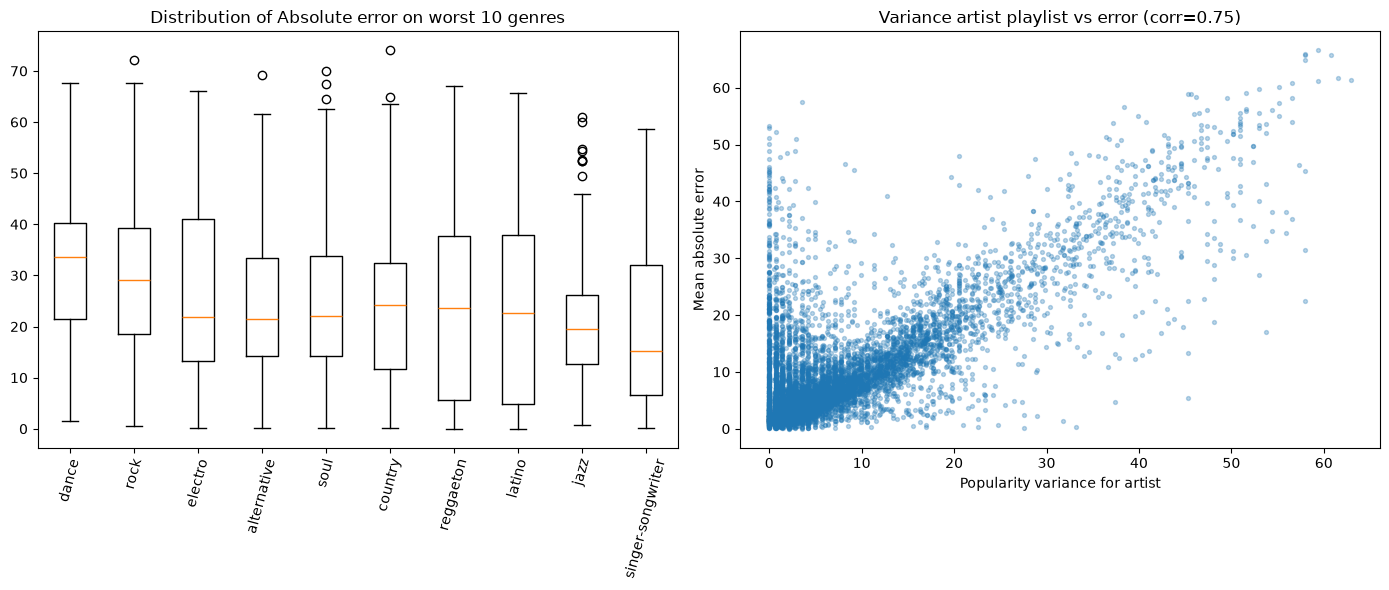

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_genres = top_worst_genres.index 
error_df["genre"] = error_df["genre"]  
box_data = [error_df[error_df["genre"]==g]["abs_error"].values for g in top_genres]
axes[0].boxplot(box_data, tick_labels=top_genres, orientation='vertical')
axes[0].tick_params(axis='x', rotation=75)
axes[0].set_title("Distribution of Absolute error on worst 10 genres")

# scatter variance vs error (to see the correlatino)
axes[1].scatter(check["variance"], check["avg_error"], alpha=0.3, s=8)
axes[1].set_xlabel("Popularity variance for artist")
axes[1].set_ylabel("Mean absolute error")
axes[1].set_title(f"Variance artist playlist vs error (corr={check.corr().iloc[0,1]:.2f})")

plt.tight_layout(); plt.show()

#### Best model evaluation on test set

In [ ]:
# validation metrics
cv_multi = cross_validate(
    best_model, X_train, y_train, cv=cv_splits,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    n_jobs = 1
)

final_model = clone(best_model)  # es. RF+artist with best hparams
final_model.fit(X_train, y_train)

y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

# test metrics
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

final_report = pd.DataFrame({
    "set": ["Train", "Test", "CV (fold avg)"],
    "rmse": [
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        -cv_multi["test_neg_root_mean_squared_error"].mean(),
    ],
    "mae": [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_test, y_pred_test),
        -cv_multi["test_neg_mean_absolute_error"].mean(),
    ],
    "r2": [
        r2_score(y_train, y_pred_train),
        r2_score(y_test, y_pred_test),
        cv_multi["test_r2"].mean(),
    ],
})
final_report

,set,rmse,mae,r2
0,Train,7.696319,4.501344,0.842517
1,Test,12.995048,8.326242,0.554687
2,CV (fold avg),12.979635,8.436304,0.552045


The final tuned Random Forest (with artist + genre target encoding) achieved 
Test RMSE = 12.99, R² = 0.55, closely matching cross-validation performance 
(RMSE = 12.97), confirming the model selection process was leakage-free and 
the reported generalization estimate is reliable. A visible train/test gap 
(Train RMSE ≈ 7.7 vs Test RMSE ≈ 13.0) reflects typical Random Forest  overfitting behavior 
at this depth.

#### Final visualization plots

In [21]:
all_attempts = pd.DataFrame([
    {"model": "Baseline (mean)",                      "rmse": 19.394171, "r2": -0.000086},
    {"model": "Linear Regression",                    "rmse": 14.853955, "r2": 0.413329},
    {"model": "Ridge",                                "rmse": 14.853849, "r2": 0.413338},
    {"model": "Lasso",                                "rmse": 19.006395, "r2": 0.039505},
    {"model": "ElasticNet",                           "rmse": 19.001799, "r2": 0.039969},
    {"model": "Random Forest",                        "rmse": 14.622808, "r2": 0.431433},
    {"model": "XGBoost",                              "rmse": 14.861326, "r2": 0.412729},
    {"model": "MLP",                                  "rmse": 14.524898, "r2": 0.439039},
    {"model": "Polynomial + Ridge",                   "rmse": 14.801185, "r2": 0.417491},
    {"model": "Ridge + artist",                       "rmse": 13.518987, "r2": 0.514042},
    {"model": "Polynomial + Ridge + artist",          "rmse": 13.484154, "r2": 0.516542},
    {"model": "XGBoost + artist",                     "rmse": 13.053563, "r2": 0.546923},
    {"model": "MLP + artist",                         "rmse": 13.176736, "r2": 0.538341},
    {"model": "Random Forest + artist",               "rmse": 13.004764, "r2": 0.550304},
    {"model": "Random Forest + artist (tuned, CV)",   "rmse": 12.979635, "r2": 0.552045},
    {"model": "Random Forest + artist (final TEST)",  "rmse": 12.995048, "r2": 0.554687},
])

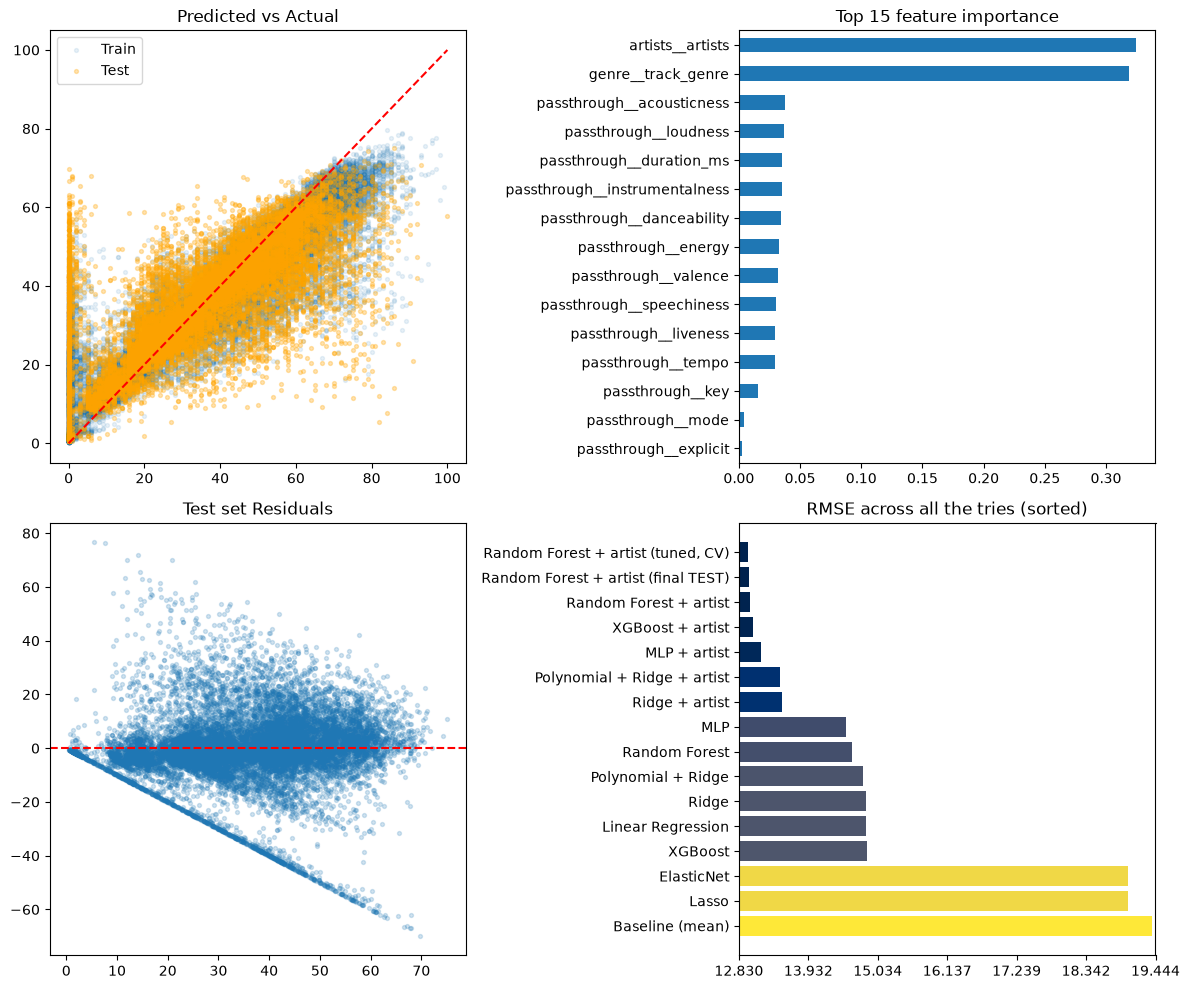

In [ ]:
#old man bro real 
from matplotlib.ticker import LinearLocator, ScalarFormatter
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Predicted vs Actual, train + test insieme
axes[0,0].scatter(y_train, y_pred_train, alpha=0.1, s=8, label="Train")
axes[0,0].scatter(y_test, y_pred_test, alpha=0.3, s=8, label="Test", color="orange")
axes[0,0].plot([0,100],[0,100],"r--")
axes[0,0].legend(); axes[0,0].set_title("Predicted vs Actual")

# 2. Feature importance (solo se RF vince)
importances = final_model.named_steps["model"].feature_importances_
feat_names = final_model.named_steps["prep"].get_feature_names_out()
imp_df = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)
imp_df.plot(kind="barh", ax=axes[0,1]); axes[0,1].invert_yaxis()
axes[0,1].set_title("Top 15 feature importance")

# 3. Residui sul test
residuals_test = y_test.values - y_pred_test
axes[1,0].scatter(y_pred_test, residuals_test, alpha=0.2, s=8)
axes[1,0].axhline(0, color="r", linestyle="--")
axes[1,0].set_title("Test set Residuals")

# 4. Confronto RMSE tra tutti i tentativi (barplot riassuntivo di tutto il percorso)
all_attempts_sorted = all_attempts.sort_values("rmse", ascending=False)
norm = (all_attempts_sorted["rmse"] - all_attempts_sorted["rmse"].min()) / \
       (all_attempts_sorted["rmse"].max() - all_attempts_sorted["rmse"].min())

cmap = plt.cm.cividis
colors = cmap(norm)
axes[1,1].barh(
    all_attempts_sorted["model"],
    all_attempts_sorted["rmse"],
    color=colors
)

axes[1,1].set_title("RMSE across all the tries (sorted)")

min_rmse = all_attempts_sorted["rmse"].min()
max_rmse = all_attempts_sorted["rmse"].max()
axes[1,1].set_xlim(min_rmse - 0.15, max_rmse + 0.05)

# Tick più dettagliati e uniformi
axes[1,1].xaxis.set_major_locator(LinearLocator(7))

# Tick con decimali puliti
axes[1,1].xaxis.set_major_locator(LinearLocator(7))
fmt = ScalarFormatter(useOffset=False)
fmt.set_powerlimits((-3, 3))
axes[1,1].xaxis.set_major_formatter(fmt)

plt.tight_layout(); plt.show()

Artist and genre feature dominate feature importance as expected because popularity depends more on who performs a track and genre trands rather than acoustic features alone. Also, both feature are targed encoded (smoothed aveage of the target), so they impact the target more (even if it is not a case of Data Leakage).

#### Conlusions

Predicting Spotify track popularity from audio features alone yields modest 
performance (R² ≈ 0.51-0.55 across linear and tree-based models), confirming 
that acoustic characteristics (energy, valence, danceability, etc.) carry 
limited signal about popularity on their own.

In [ ]:
# saving final model for future tests
import joblib
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']